In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування відображення
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

In [3]:
DATA_PATH = "../data/raw/healthcare-dataset-stroke-data.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")

print("Список колонок:")
print(df.columns.tolist())

print("\nІнформація про датасет:")
df.info()

Розмір датасету: 5110 рядків, 12 колонок
Список колонок:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             511

In [5]:
## Перевірка пропусків

missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing_abs,
    "missing_percent": missing_pct.round(2)
})

display(missing_table[missing_table["missing_count"] > 0])

display(missing_table)

,missing_count,missing_percent
bmi,201,3.93
id,0,0.00
age,0,0.00
gender,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
work_type,0,0.00
ever_married,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00


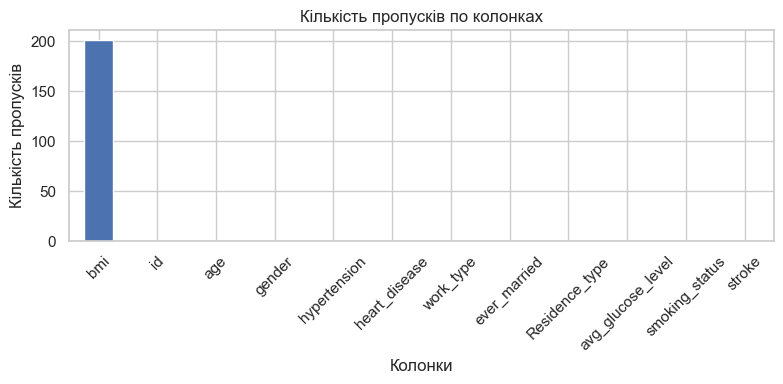

In [6]:
plt.figure(figsize=(8, 4))
missing_table["missing_count"].plot(kind="bar")
plt.title("Кількість пропусків по колонках")
plt.ylabel("Кількість пропусків")
plt.xlabel("Колонки")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
## Розподіл цільової змінної

target_counts = df["stroke"].value_counts().sort_index()
target_pct = (df["stroke"].value_counts(normalize=True).sort_index() * 100).round(2)

target_table = pd.DataFrame({
    "count": target_counts,
    "percent": target_pct
})
target_table.index.name = "stroke"

display(target_table)

print(f"Частка позитивного класу (stroke=1): {target_pct.loc[1]}%")

Частка позитивного класу (stroke=1): 4.87%


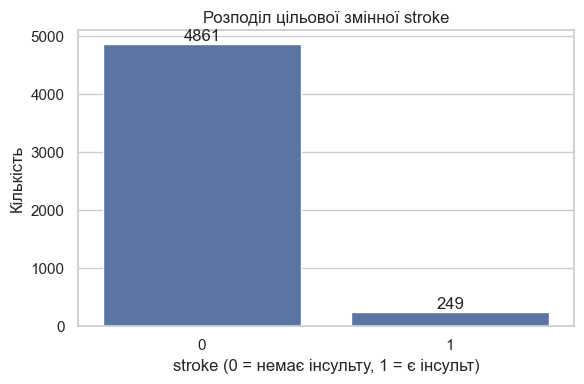

In [8]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="stroke")
plt.title("Розподіл цільової змінної stroke")
plt.xlabel("stroke (0 = немає інсульту, 1 = є інсульт)")
plt.ylabel("Кількість")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

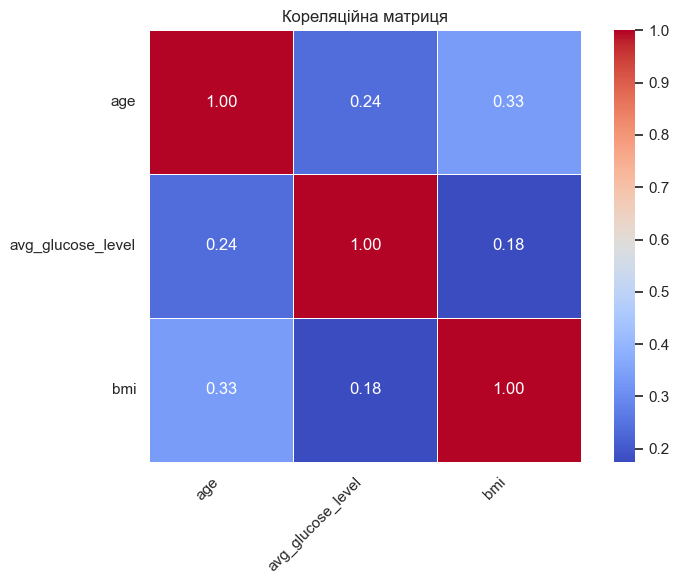

In [11]:
## Матриця кореляції

corr_matrix = df[["age", "avg_glucose_level", "bmi"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.title("Кореляційна матриця")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()